Importar Bibliotecas

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Fazer a leitura do arquivo

In [64]:
df =pd.read_csv('googleplaystore.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


Gráfico contendo os 5 apps com mais instalações

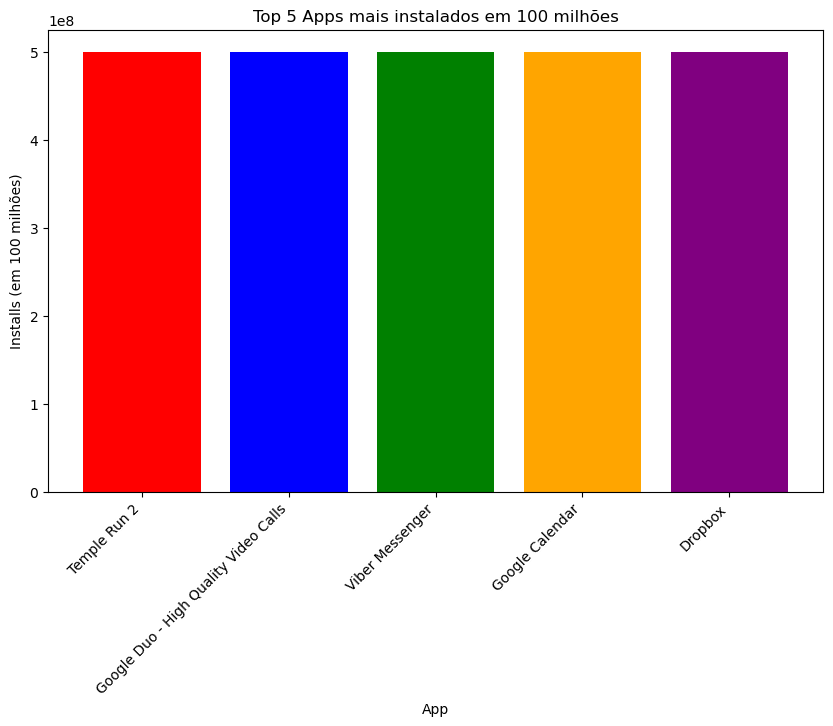

In [65]:
df_filtrado = df[df['Installs'] != 'Free']
df_ordenado = df_filtrado.sort_values('Installs', ascending=False)
df_selected = df_ordenado[['App', 'Installs']]

df_selected.loc[:, 'Installs'] = pd.to_numeric(df_selected['Installs'].str.replace('[+,]', '', regex=True))
df_5 = df_selected.head(5)

colors = ['red', 'blue', 'green', 'orange', 'purple']
plt.figure(figsize=(10, 6))
plt.bar(df_5['App'], df_5['Installs'], color=colors)
plt.title('Top 5 Apps mais instalados em 100 milhões')
plt.xlabel('App')
plt.ylabel('Installs (em 100 milhões)')
plt.xticks(rotation=45, ha='right')
plt.show()


Gráfico de pie chart mostrando as principais categorias dos apps(o ideal é não conter mais que 7)

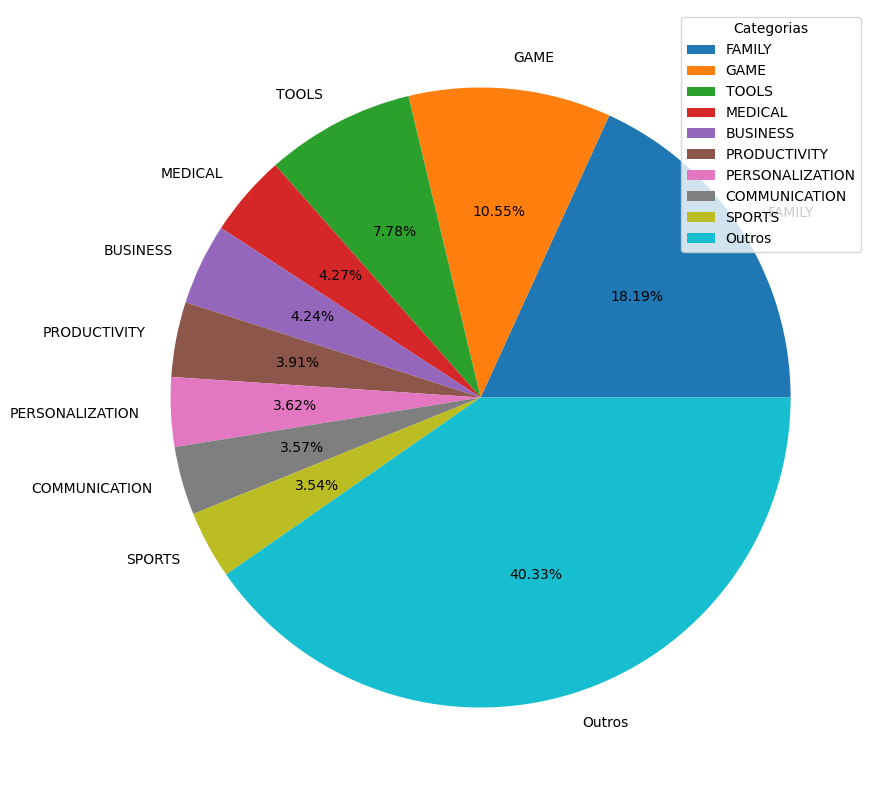

In [66]:
df['Frequencia'] = df.groupby('Category')['Category'].transform('count')
df_ordenado = df.drop_duplicates(subset=['Category', 'Frequencia']).sort_values('Frequencia', ascending=False)
top_9 = df_ordenado.head(9)
# Calcular a soma dos demais
soma_outros = df_ordenado['Frequencia'][9:].sum()
# Criar a DataFrame para "Outros"
df_outros = pd.DataFrame({'Category': ['Outros'], 'Frequencia': [soma_outros]})
# Concatenar os dados
df_final = pd.concat([top_9, df_outros], ignore_index=True)
plt.figure(figsize=(10, 18))
plt.pie(df_final['Frequencia'], labels=df_final['Category'], autopct='%1.2f%%')
plt.legend(title="Categorias")
plt.show()

App mais caro existente

In [67]:
df_filtrado=df[df['Type'] == 'Paid']
#usar regex novamente para converter string para float
df['Price'] = df_filtrado['Price'].replace('[\$,]', '', regex=True).astype(float)
df_maior = df.sort_values(by='Price', ascending=False)
df_resultado = (df_maior[['App', 'Price']]).head(1)
df_resultado


,App,Price
4367,I'm Rich - Trump Edition,400.0


Quantos apps foram classificados como Mature+17

In [68]:
df_filtrado = df[df['Content Rating'] == 'Mature 17+']
total_apps = df_filtrado['Content Rating'].count()
df_resultado = pd.DataFrame({
    'Content Rating': ['Mature 17+'],
    'Total apps': [total_apps]
})
df_resultado

,Content Rating,Total apps
0,Mature 17+,499


Top 10 apps por número de reviews

In [70]:
#print(df['Reviews'].dtype)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df_agrupado = df.groupby('App', as_index=False)['Reviews'].sum()
df_maior = df_agrupado.sort_values(by='Reviews', ascending=False)
df_resultado = (df_maior[['App', 'Reviews']]).head(10)
df_resultado



,App,Reviews
5399,Instagram,266241989.0
9042,WhatsApp Messenger,207348304.0
2564,Clash of Clans,179558781.0
6166,Messenger – Text and Video Chat for Free,169932272.0
8080,Subway Surfers,166331958.0
2364,Candy Crush Saga,156993136.0
4328,Facebook,156286514.0
101,8 Ball Pool,99386198.0
2561,Clash Royale,92530298.0
7890,Snapchat,68045010.0


Dois cálculos,um em formato de lista e outro em formato de valor

In [71]:
#lista dos apps gratis e dos apps pagos
lista_freeApps = [app for app, tipo in zip(df['App'], df['Type']) if tipo == 'Free']
lista_paidApps = [app for app,tipo in zip(df['App'],df['Type']) if tipo =='Paid']
#print(lista_freeApps)
#print(lista_paidApps)


#mostrar o valor do genero mais popular nos apps
df_generos = df['Genres'].value_counts()
top_genero = df_generos.idxmax()
total_top_genero = df_generos.max()
df_resultado = pd.DataFrame({
    'Top Genre': [top_genero],
    'Total de apps do gênero': [total_top_genero]
})
df_resultado


,Top Genre,Total de apps do gênero
0,Tools,842


Outras 2 formas de gráfico de exibição dos indicadores

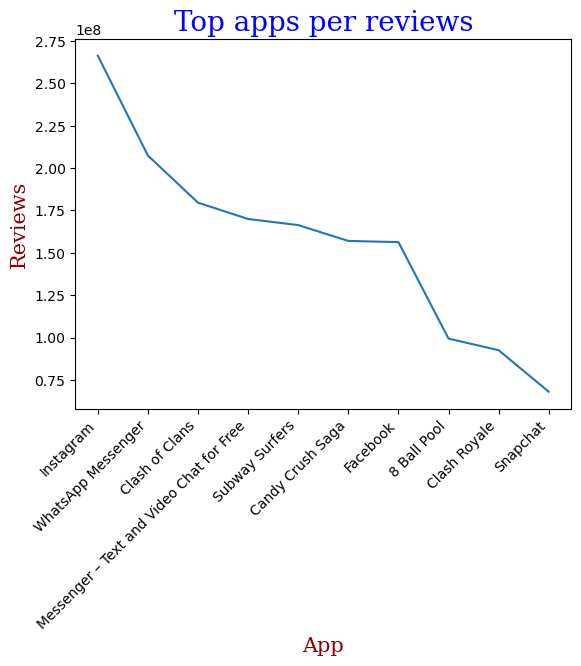

In [77]:
df['Reviews'] = pd.to_numeric(df['Reviews'])
df_agrupado = df.groupby('App', as_index=False)['Reviews'].sum()
df_maior = df_agrupado.sort_values(by='Reviews', ascending=False)
df_resultado = (df_maior[['App', 'Reviews']]).head(10)

font1 = {'family':'serif','color':'blue','size':20}
font2 = {'family':'serif','color':'darkred','size':15}
plt.xticks(rotation=45, ha='right')

plt.title("Top apps per reviews", fontdict = font1)
plt.xlabel("App", fontdict = font2)
plt.ylabel("Reviews", fontdict = font2)

plt.plot(df_resultado['App'],df_resultado['Reviews'])
plt.show()

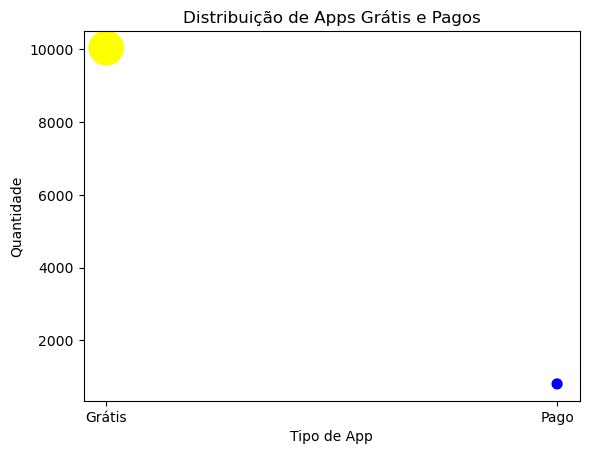

In [89]:
num_freeApps = sum(1 for app, tipo in zip(df['App'], df['Type']) if tipo == 'Free')
num_paidApps = sum(1 for app, tipo in zip(df['App'], df['Type']) if tipo == 'Paid')
categories = ['Grátis', 'Pago']
counts =[num_freeApps, num_paidApps]
cor=['yellow','blue']
sizes= np.array([600,50])
plt.scatter(categories, counts,color=cor,s=sizes)
plt.xlabel('Tipo de App')
plt.ylabel('Quantidade')
plt.title('Distribuição de Apps Grátis e Pagos')
plt.show()